In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4o")

In [2]:
class State(TypedDict):

    document: str
    summary: str
    sentiment: str
    key_points: str
    recommendation: str
    final_analysis: str

In [3]:
def get_summary(state: State):
    response = llm.invoke(
        f"이 문서를 3문장으로 요약해 주세요. 문서: {state["document"]}"
    )
    return {
        "summary": response.content,
    }


def get_sentiment(state: State):
    response = llm.invoke(
        f"이 문서의 Sentiment(감정)와 Tone(어조)을 분석해 주세요. 문서: {state["document"]}"
    )
    return {
        "sentiment": response.content,
    }


def get_key_points(state: State):
    response = llm.invoke(
        f"이 문서에서 가장 중요한 포인트 5가지를 나열해 주세요. 문서: {state["document"]}"
    )
    return {
        "key_points": response.content,
    }


def get_recommendation(state: State):
    response = llm.invoke(
        f"문서의 내용을 바탕으로 권장되는 다음 단계(Next Steps) 3가지를 제시해 주세요. 문서: {state["document"]}"
    )
    return {
        "recommendation": response.content,
    }


# state["key_point"] -> state에 없음(error) -> state.get("key_points", "")
def get_final_analysis(state: State):
    response = llm.invoke(
        f"""
    다음 리포트에 대한 분석 내용을 작성해 주세요.

    DOCUMENT ANALYSIS REPORT
    ========================

    EXECUTIVE SUMMARY:
    {state["summary"]}

    SENTIMENT ANALYSIS:
    {state["sentiment"]}

    KEY POINTS:
    {state.get("key_points", "")}

    RECOMMENDATIONS:
    {state.get("recommendation", "N/A")}
    """
    )
    return {
        "final_analysis": response.content,
    }

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("get_summary", get_summary)
graph_builder.add_node("get_sentiment", get_sentiment)
graph_builder.add_node("get_key_points", get_key_points)
graph_builder.add_node("get_recommendation", get_recommendation)
graph_builder.add_node("get_final_analysis", get_final_analysis)


graph_builder.add_edge(START, "get_summary")
graph_builder.add_edge(START, "get_sentiment")
graph_builder.add_edge(START, "get_key_points")
graph_builder.add_edge(START, "get_recommendation")

graph_builder.add_edge("get_summary", "get_final_analysis")
graph_builder.add_edge("get_sentiment", "get_final_analysis")
graph_builder.add_edge("get_key_points", "get_final_analysis")
graph_builder.add_edge("get_recommendation", "get_final_analysis")

graph_builder.add_edge("get_final_analysis", END)


graph = graph_builder.compile()

In [5]:
with open("fed_transcript.md", "r", encoding="utf-8") as f:
    document = f.read()

for chunk in graph.stream(
    {"document": document},
    stream_mode="updates",
):
    print(chunk, "\n")

{'get_summary': {'summary': 'The Federal Reserve has decided to lower the interest rate by a quarter of a percentage point to support its dual mandate of maximum employment and stable prices amidst increasing inflation and rising downside risks to employment. Recent economic data indicates a moderation in the growth of economic activity, with a slowdown in consumer spending and a weaker labor market, although business investments have increased. The Federal Open Market Committee remains focused on achieving its long-term inflation goal of 2% while responding to evolving economic conditions and maintaining its independence from political influences.'}} 

{'get_recommendation': {'recommendation': "Based on the content of the document, here are three recommended next steps:\n\n1. **Continue Monitoring Economic Data:**\n   - The Federal Reserve should continue to closely monitor incoming economic data, particularly related to unemployment rates, inflation trends, and consumer spending patt

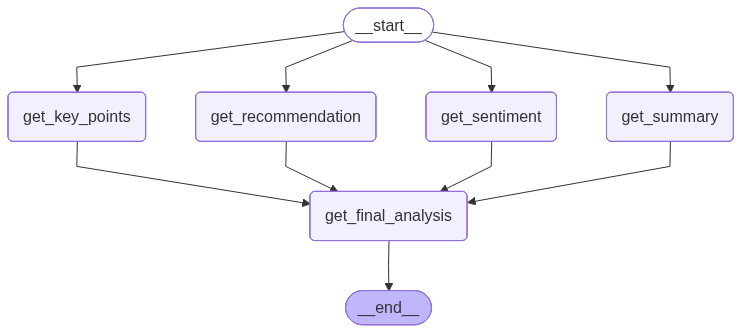

In [6]:
graph